In [1]:
# loading requiered libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline
sns.set()

In [2]:
# use warnings library to clear updates warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# The data is in a .data file and separated by commas.
# The first few lines are metadata and should be skipped.

features = [
    "ID number",
    "Diagnosis",
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",
    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave points_se",
    "symmetry_se",
    "fractal_dimension_se",
    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data",
                 comment='#', sep=',',names=features)

In [4]:
# print the whole data frame
df

,ID number,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
# displaying the first 10 rows in the data frame
df.head(10)

,ID number,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [6]:
# displaying the last 5 rows in the data frame
df.tail()

,ID number,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [7]:
# displaying some information about the data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID number                569 non-null    int64  
 1   Diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

data types for each column is correct (except "id number" column which we will delete)

# EDA

dropping 'id number' column 

In [8]:
# dropping id number column caues it’s not neccessary
df.drop(columns='ID number' , inplace=True)
df

,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


checking for null values

In [9]:
df.isna().sum()

Diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

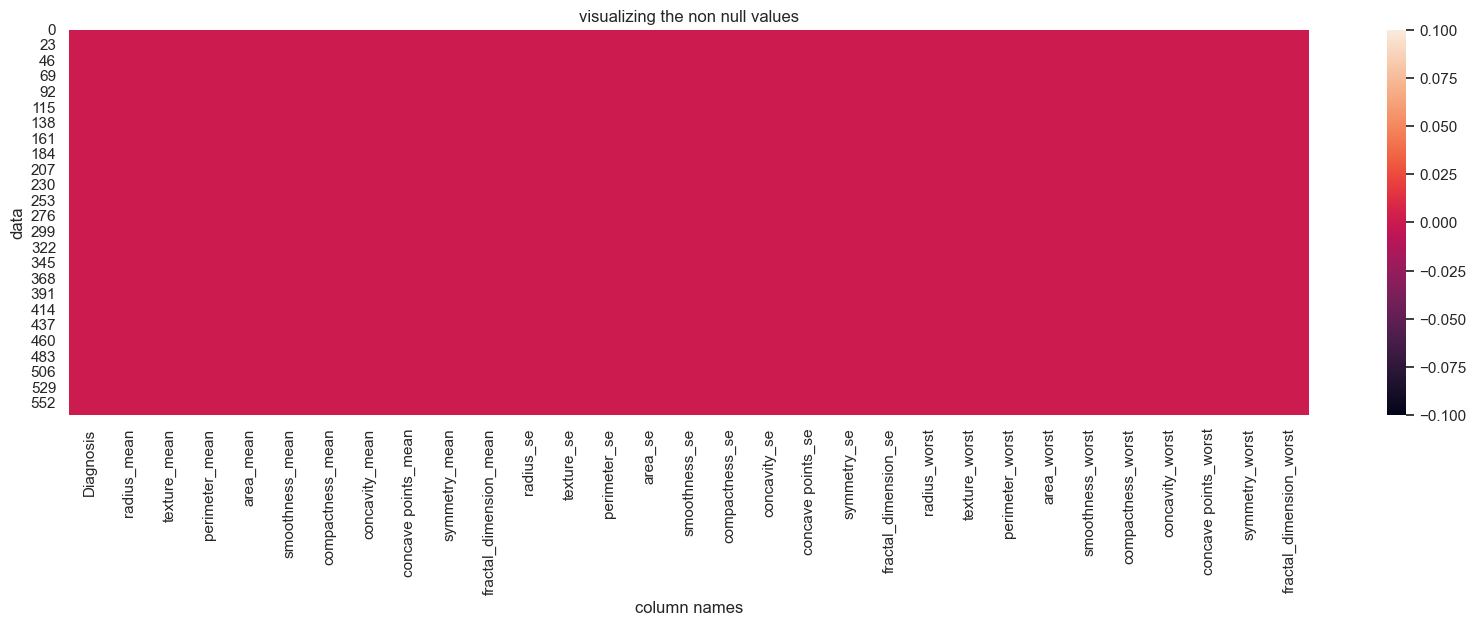

In [10]:
# visualizing the null values for more checking
plt.figure(figsize=(20,5))
sns.heatmap(df.isna())
plt.title('visualizing the non null values')
plt.xlabel('column names')
plt.ylabel('data')
plt.show()

checking for duplicates

In [11]:
# print the total number of duplicates in the data frame
df.duplicated().sum()

0

In [12]:
# display summary statistical for the numerical columns in the data frame
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [13]:
# displaying the shape of the data frame in the form of (rows , columns)
df.shape

(569, 31)

In [14]:
# displaying each data type for each column in the data frame
df.dtypes

Diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst            float64
concave points_worst

# data visualization

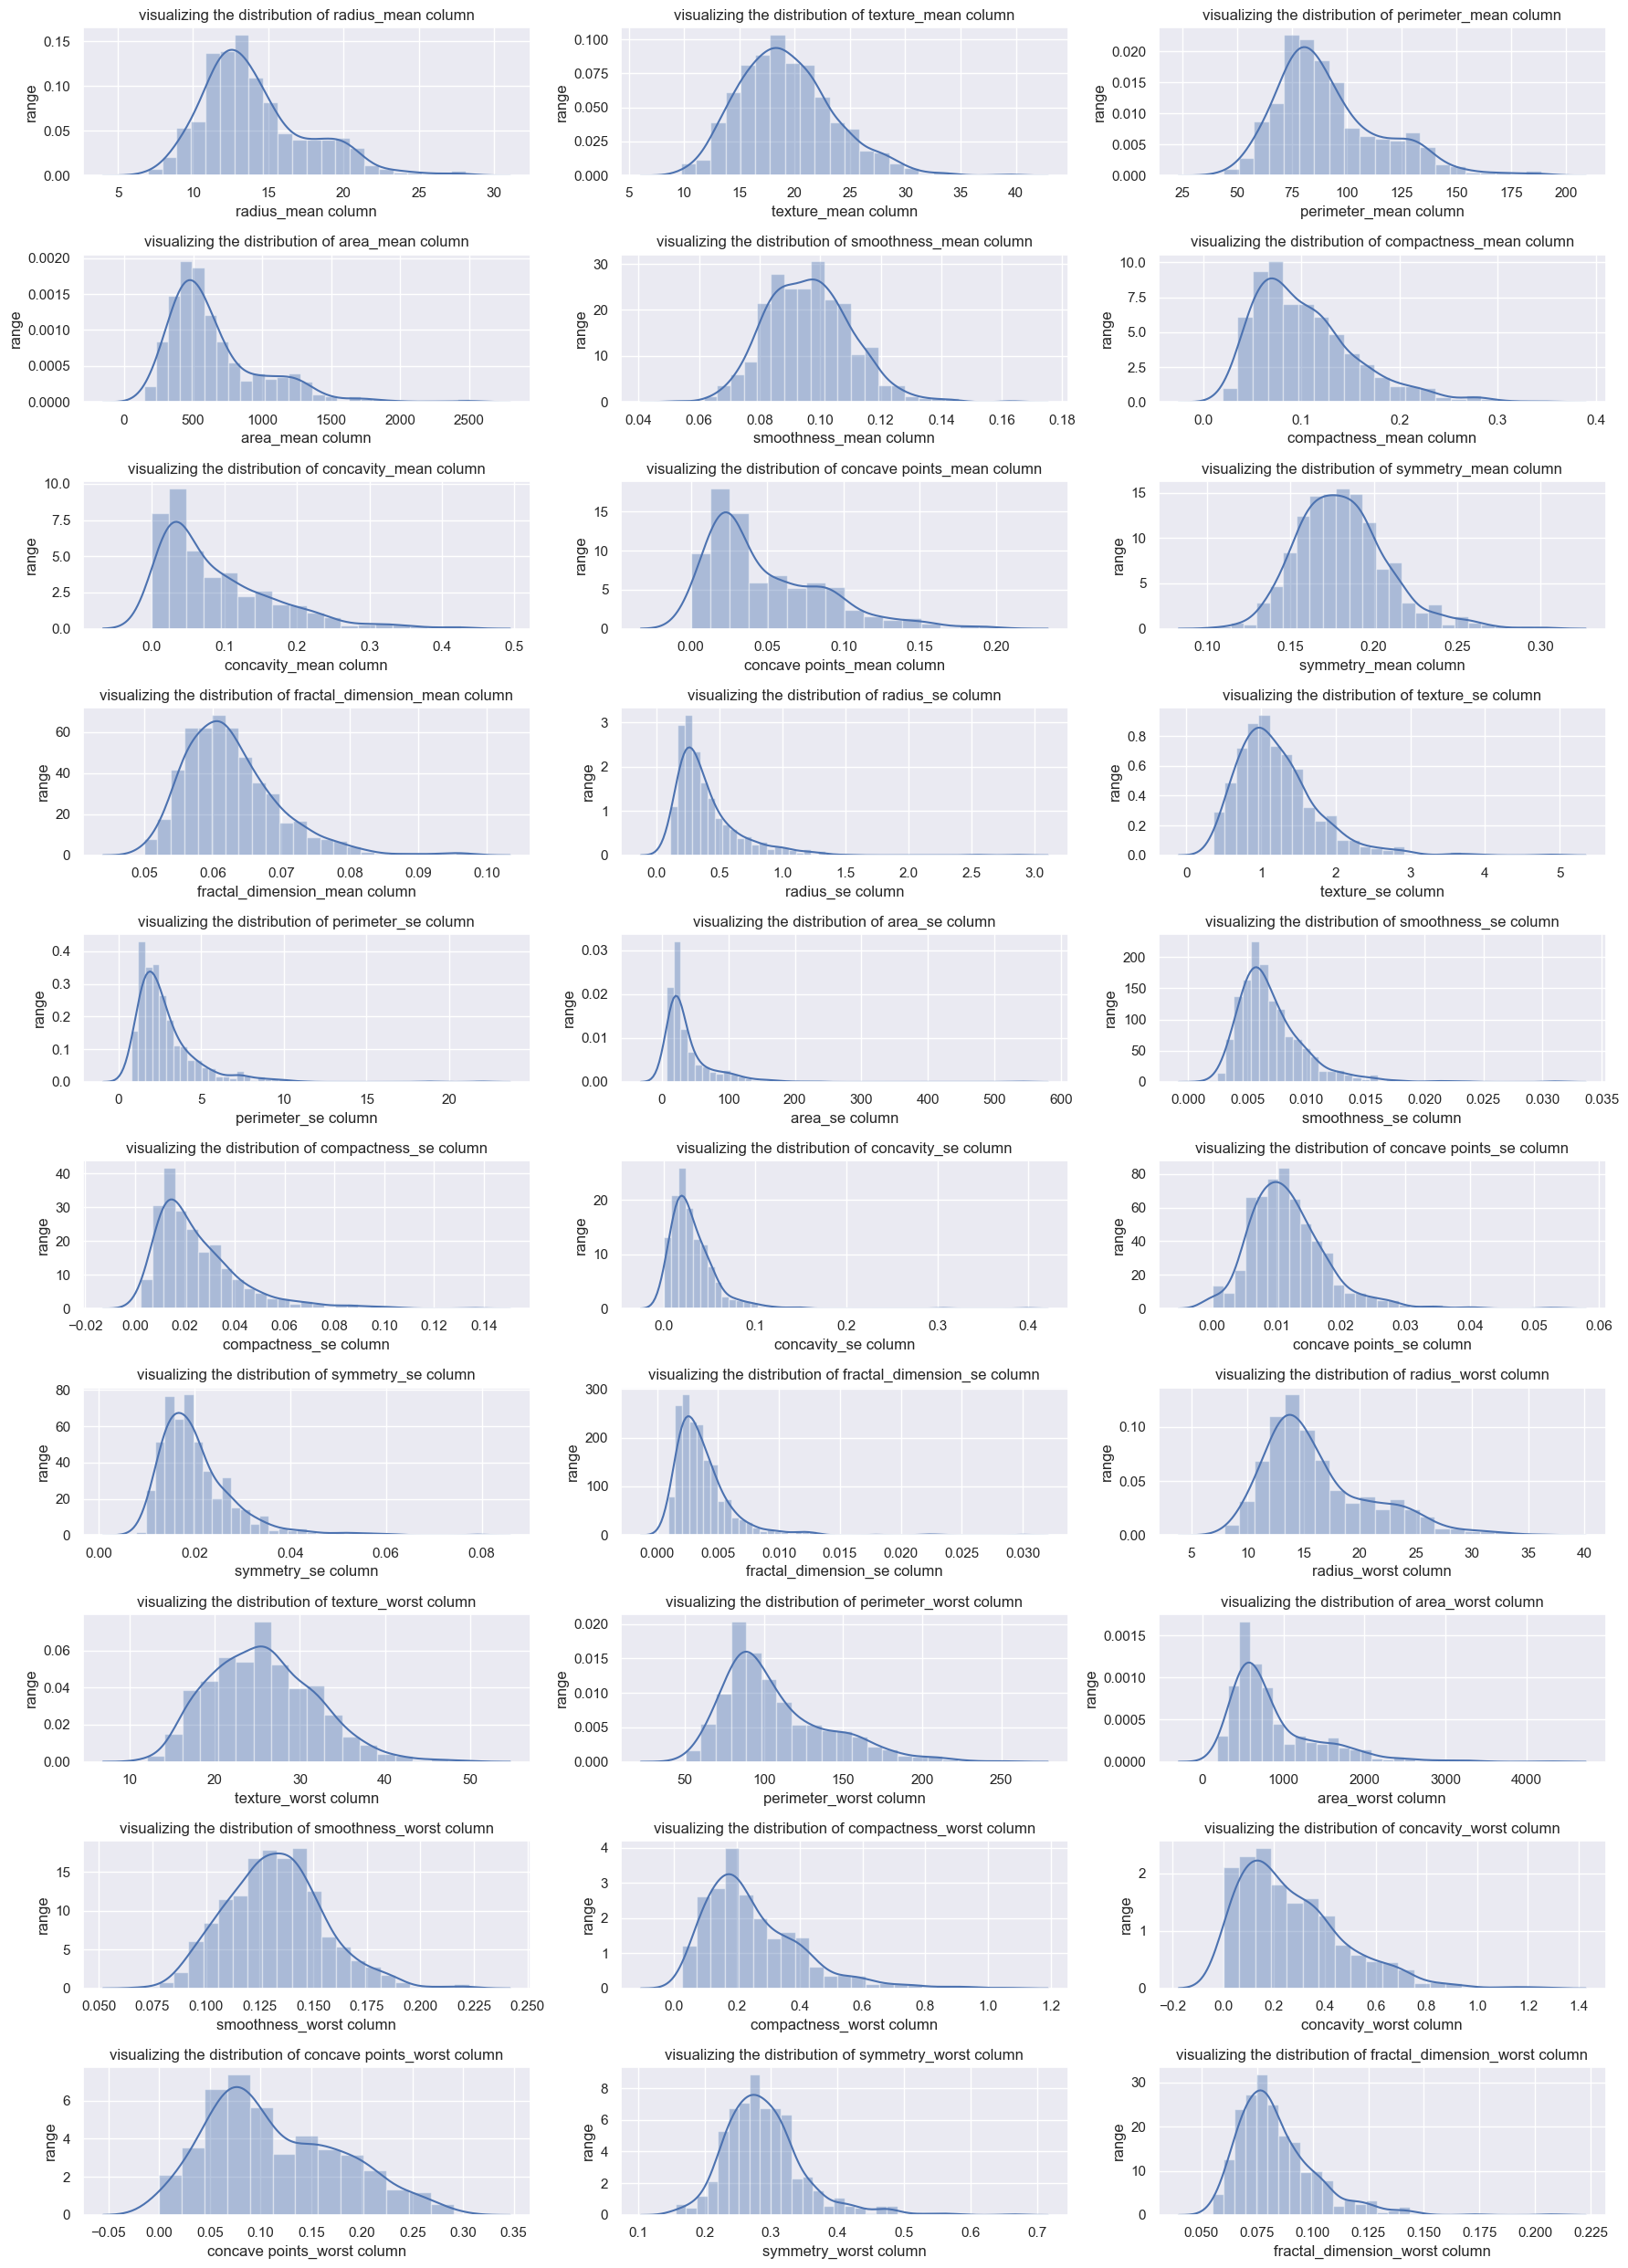

In [15]:
# visualizing the distribution of the numerical features
plt.figure(figsize=(18,25))
index = 1 # just a counter to identify which subplot to draw in

for col in df.select_dtypes(include = ['float64']):
    plt.subplot(10,3,index)
    sns.distplot( df[col])
    plt.title(f'visualizing the distribution of {col} column' )
    plt.xlabel(f'{col} column')
    plt.ylabel('range')
    index +=1
plt.tight_layout() 
plt.show()
    


so since the whole data either almost normal distribution or right skewed so i will use z-score scaling for alomst normally distributed data and log transform for right skewed data

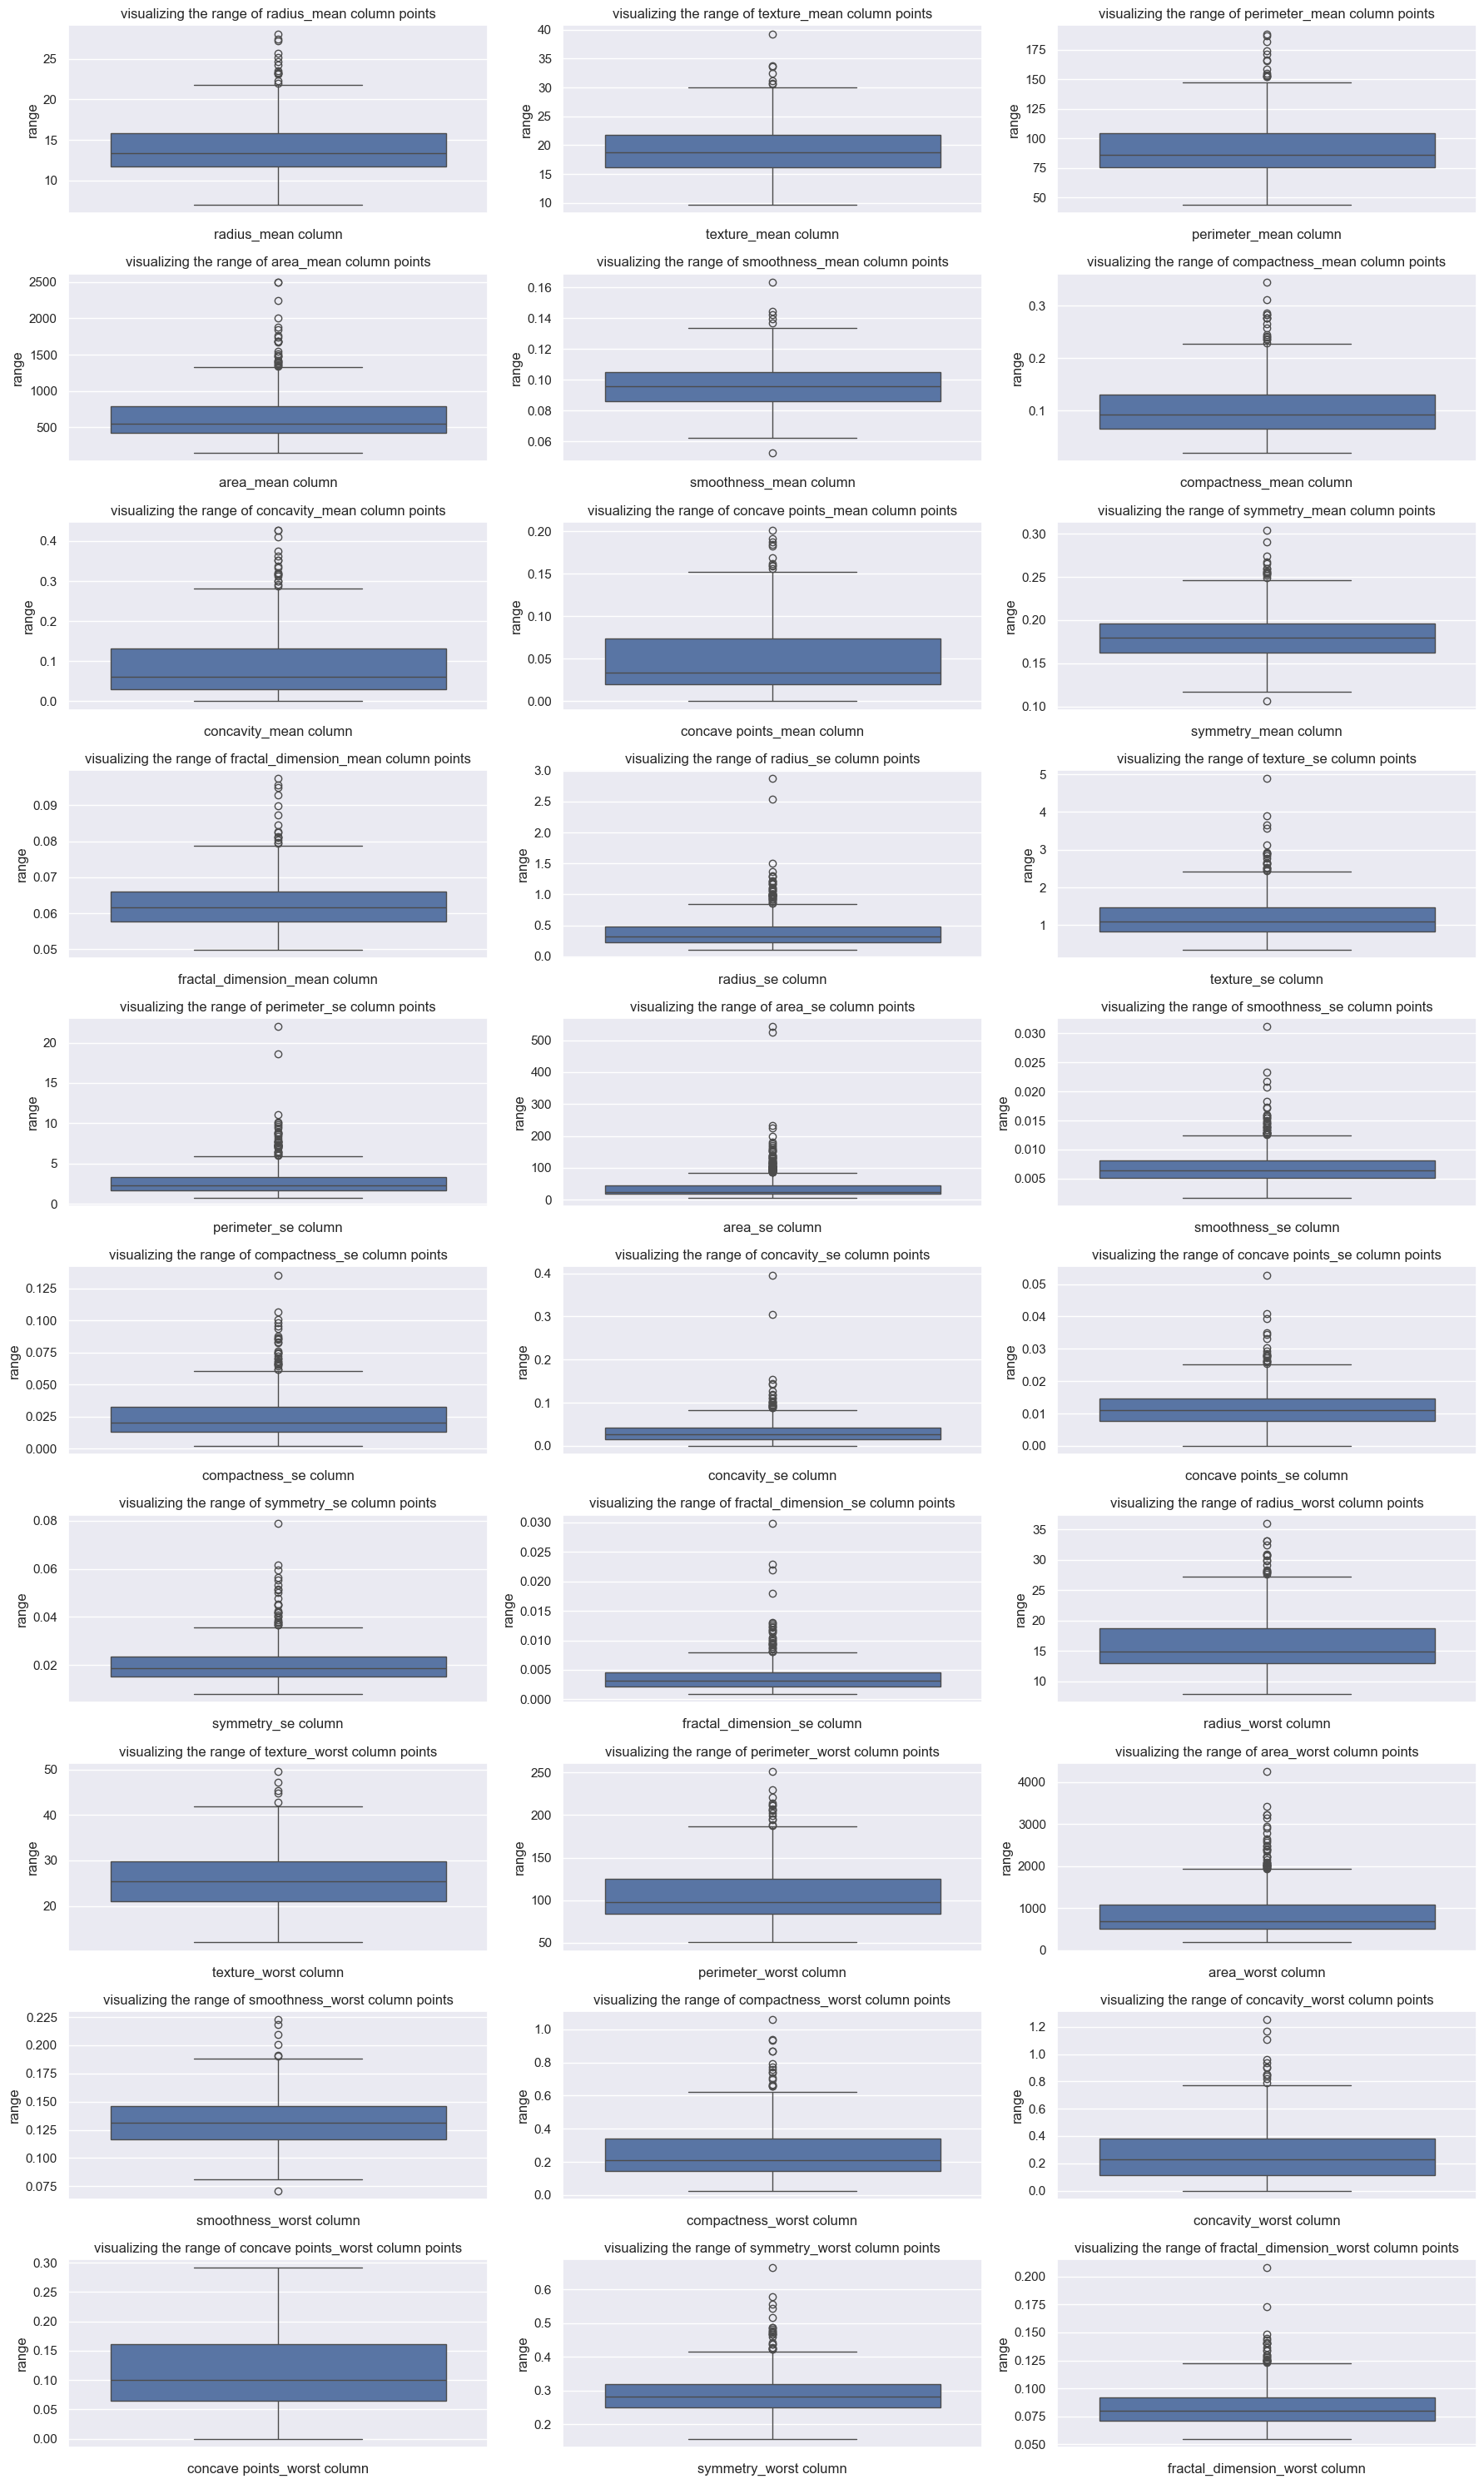

In [16]:
# visualizing outliers
plt.figure(figsize=(18,30))
index = 1 # just a counter to identify which subplot to draw in

for col in df.select_dtypes(include = ['float64']):
    plt.subplot(10,3,index)
    sns.boxplot(data = df  , y = col)
    plt.title(f'visualizing the range of {col} column points' )
    plt.xlabel(f'{col} column')
    plt.ylabel('range')
    index +=1
plt.tight_layout() 
plt.show()

some columns has huge amount of outliers so i won’t drop them

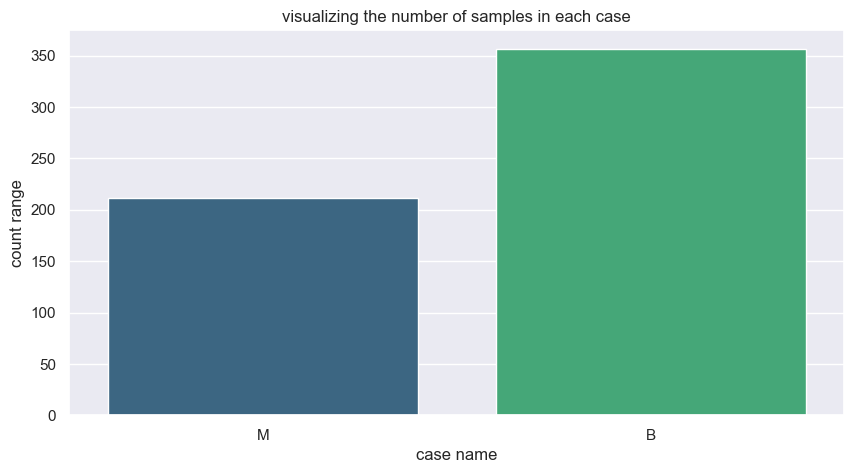

In [17]:
# visualizing the count of every class in the target column
plt.figure(figsize=(10,5))
sns.countplot(data = df , x = 'Diagnosis' , palette='viridis')
plt.title('visualizing the number of samples in each case')
plt.xlabel('case name')
plt.ylabel('count range')
plt.show()

so the number of samples from each class is not the same , we have unbalanced data

In [18]:
# to know the exact number of samples in each class
df['Diagnosis'].value_counts()

B    357
M    212
Name: Diagnosis, dtype: int64

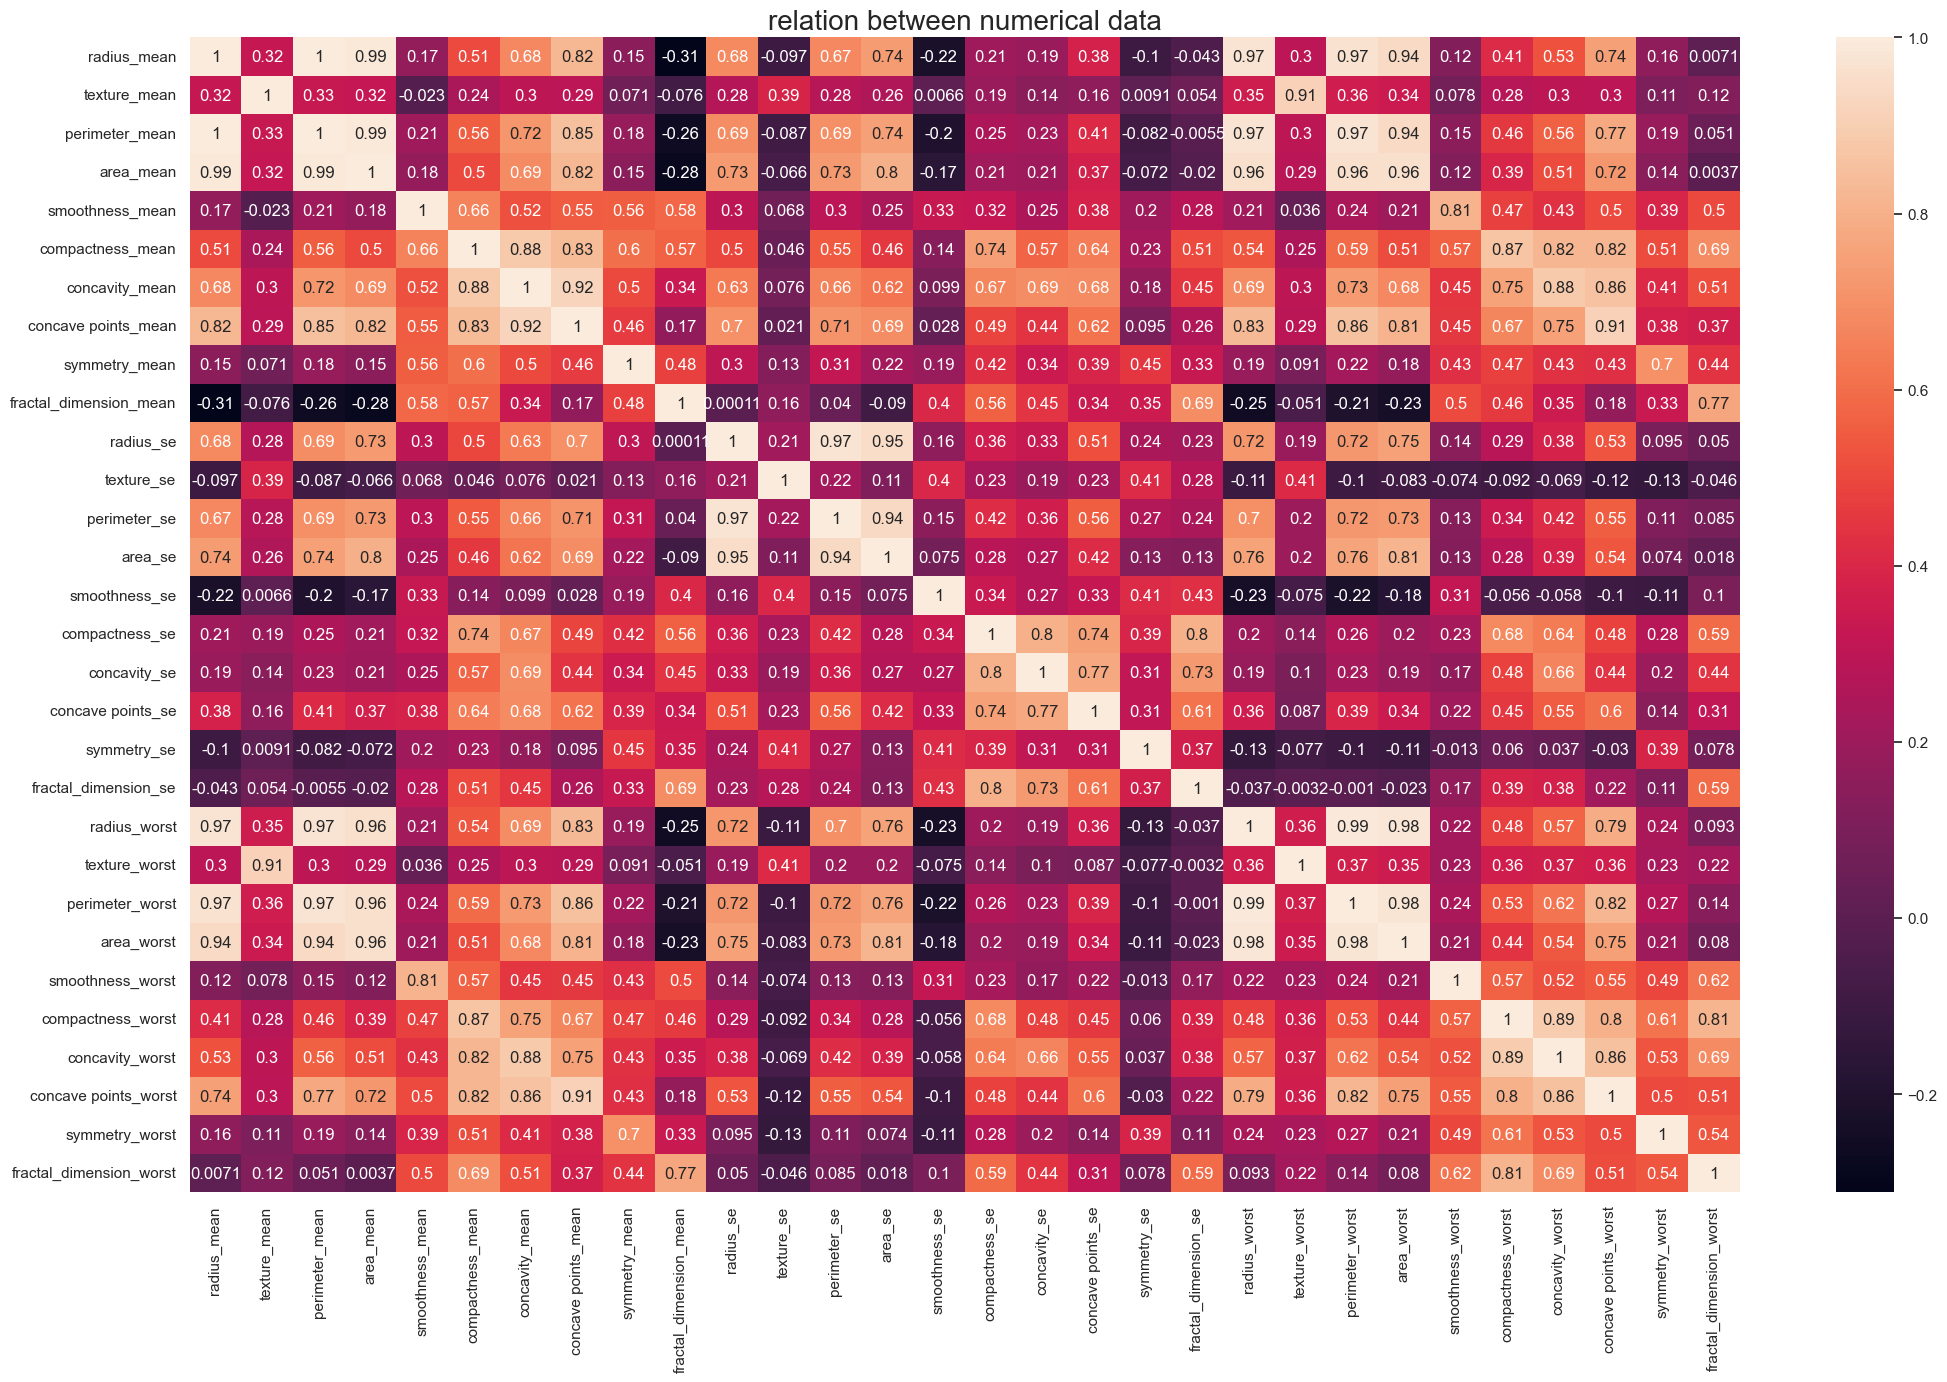

In [19]:
# displaying the correlation between numerical columns as heatmap
relation = df.select_dtypes(include='float64').corr()
plt.figure(figsize=(25,15))
sns.heatmap(relation , annot=True)
plt.title('relation between numerical data' , fontsize = 20)
plt.show()


the features with the strong linear relationship in so close to 1

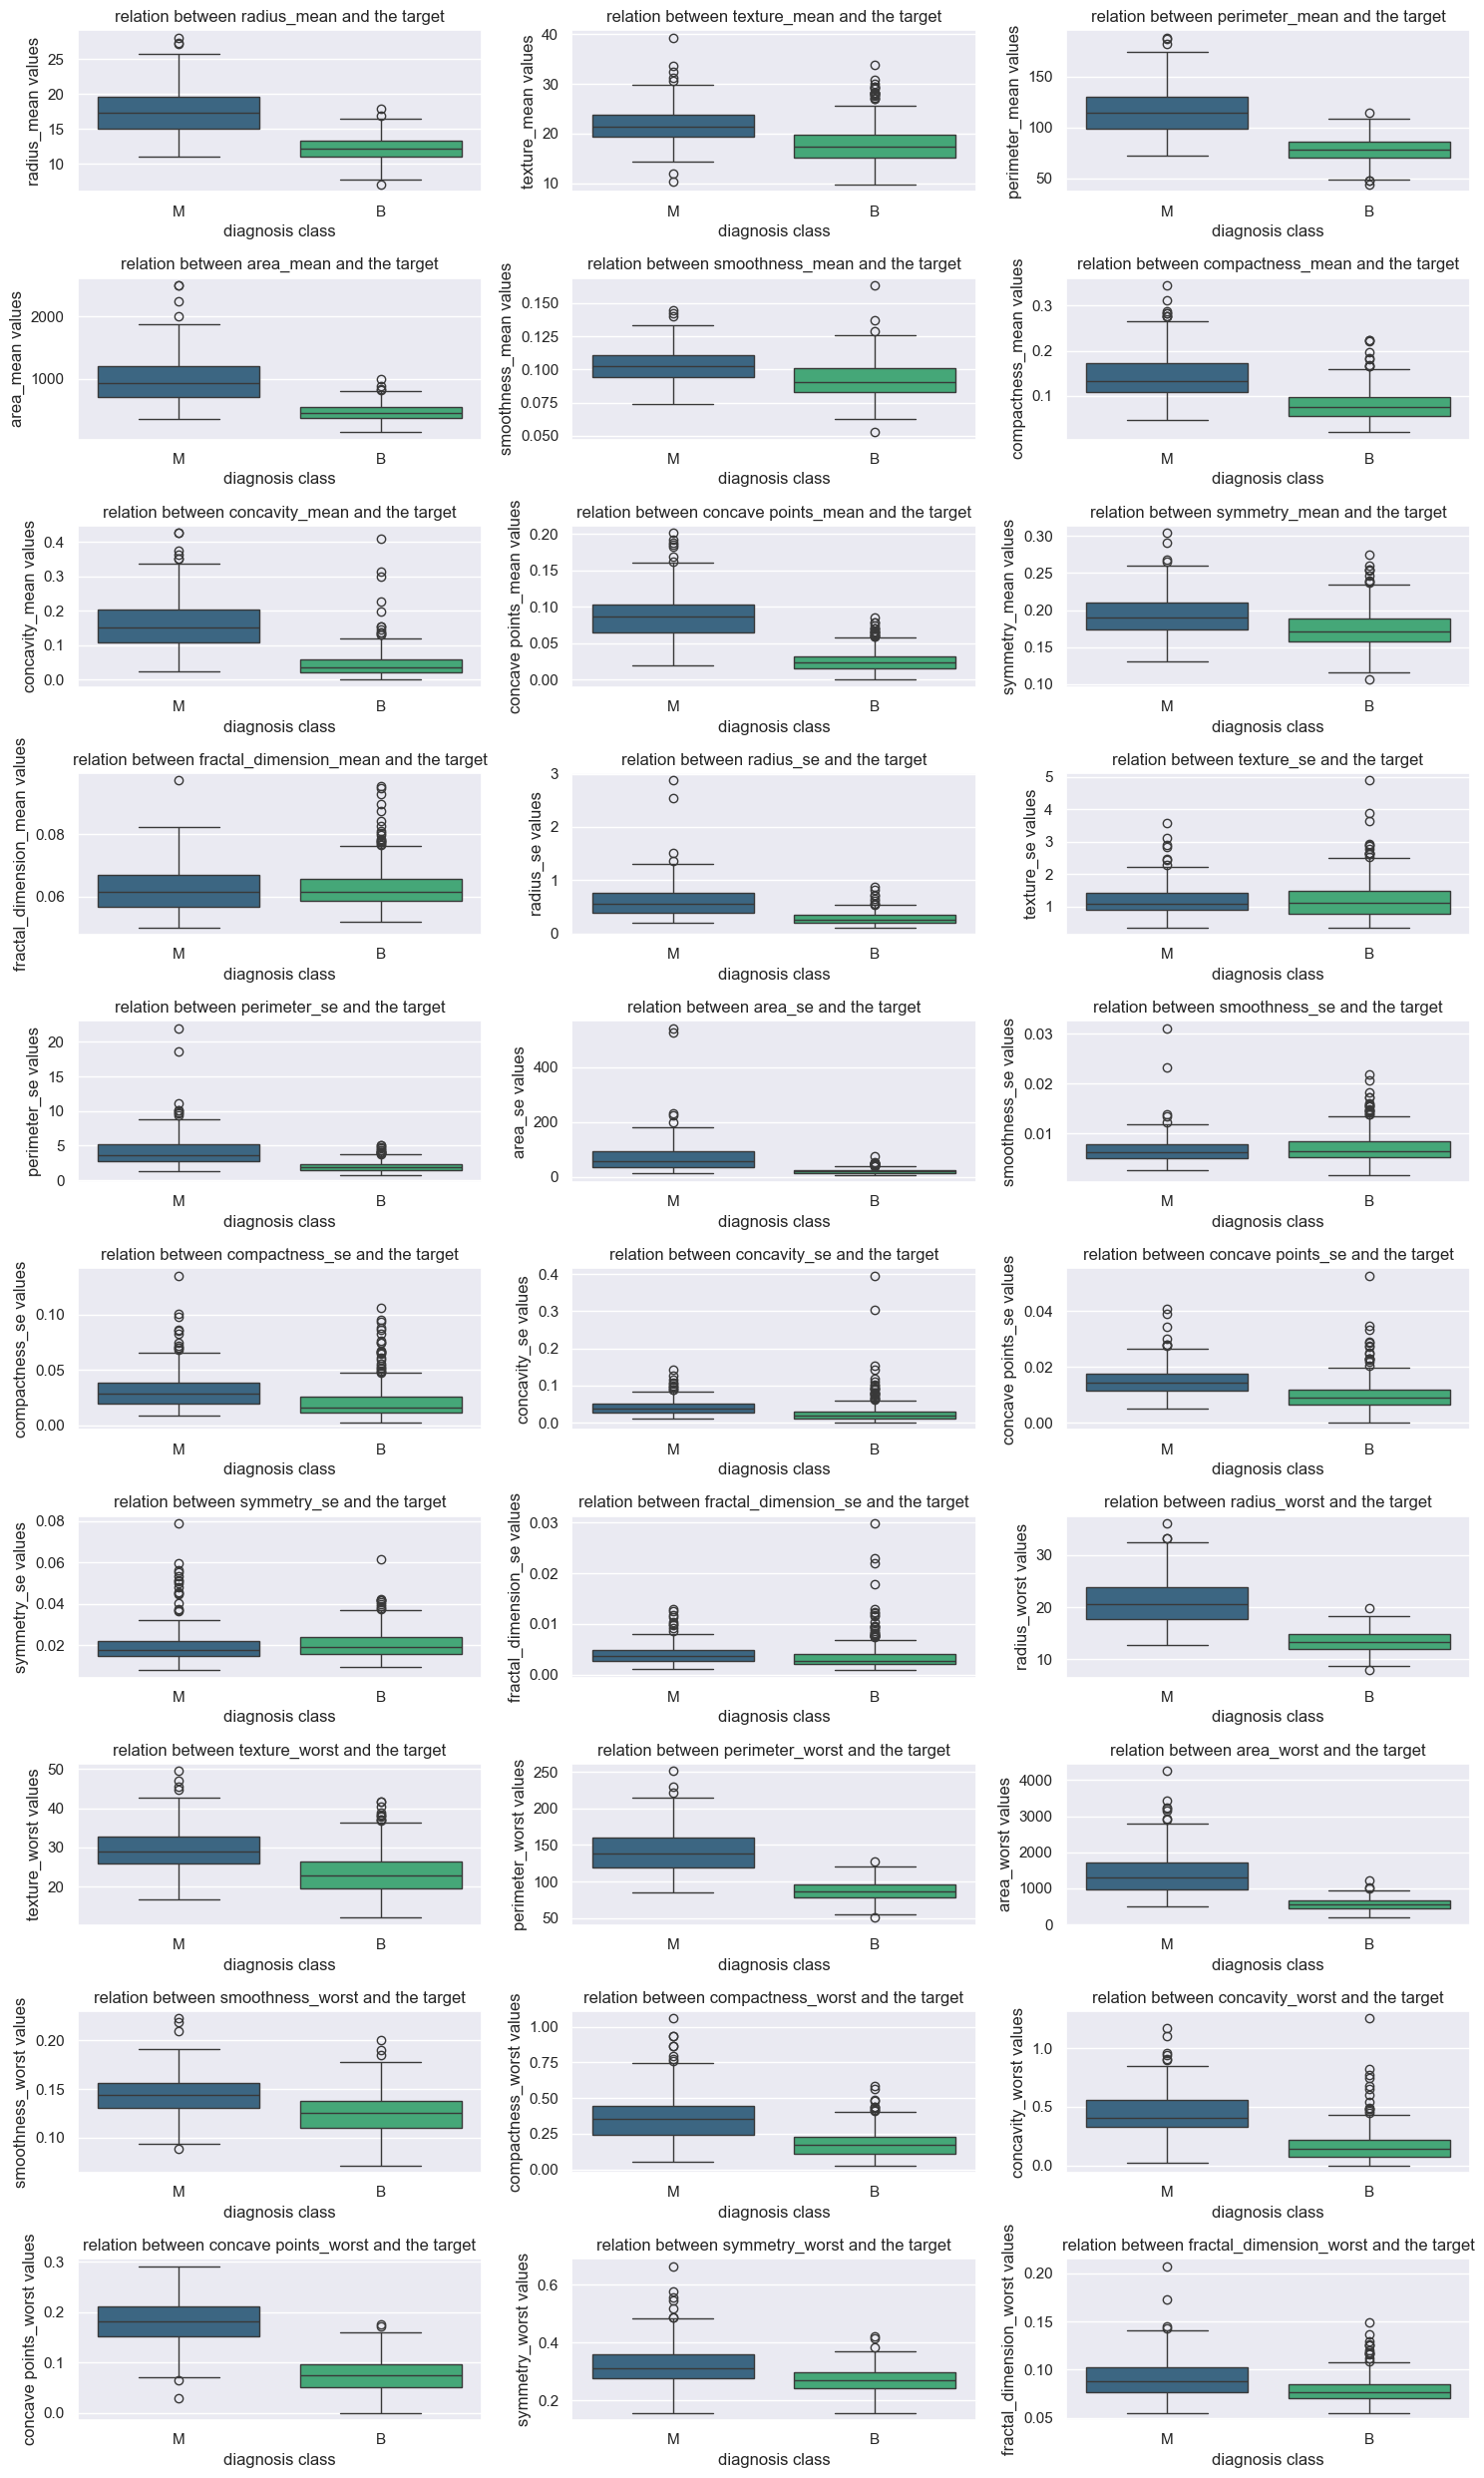

In [20]:
# comparing the distribution of the numerical columns based on the target
plt.figure(figsize=(15,25))
index = 1
for col in df.select_dtypes(include='float64'):
    plt.subplot(10,3,index)
    sns.boxplot(data = df , x = 'Diagnosis' , y = col , palette='viridis')
    plt.title(f'relation between {col} and the target')
    plt.xlabel('diagnosis class')
    plt.ylabel(f'{col} values')
    index += 1
plt.tight_layout()
plt.show()

after visualizing the relation between each numerical feature and traget values :
- either the ranges between Malignant and Benign is almost the same
- or the range of Malignant is higher thant the ranges of Benign
- sometimes the range of Benign is higher than Malignant due to outliers and vise versa

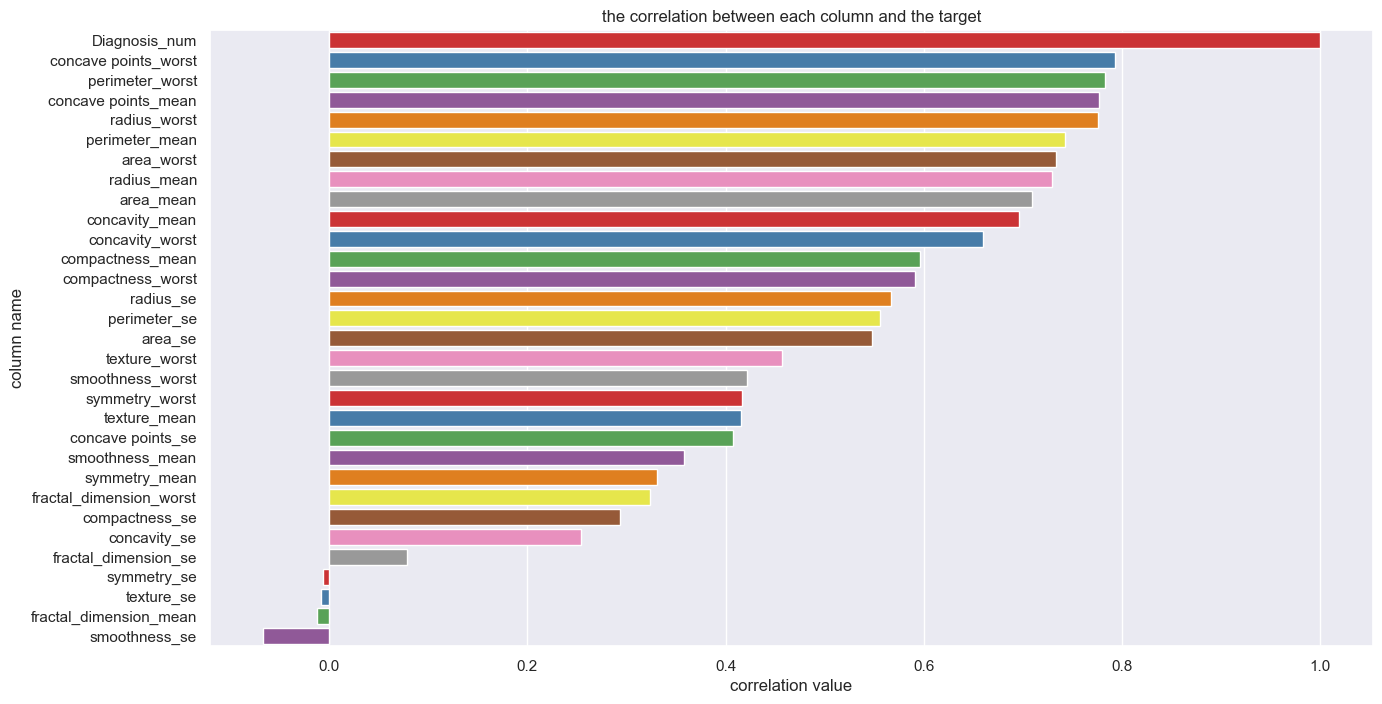

In [21]:
# displaying the correlation between each feature and the target from the highest to the lowest
df['Diagnosis_num'] = df['Diagnosis'].map({'B':0, 'M':1})

correlation = df.select_dtypes(exclude='object').corr()['Diagnosis_num'].sort_values(ascending=False)

plt.figure(figsize=(15,8))
sns.barplot(data = correlation.reset_index() , y = 'index' , x = 'Diagnosis_num' , palette='Set1')
plt.title('the correlation between each column and the target')
plt.xlabel('correlation value')
plt.ylabel('column name')
plt.show()

concave points worst has the highest correlation in the data

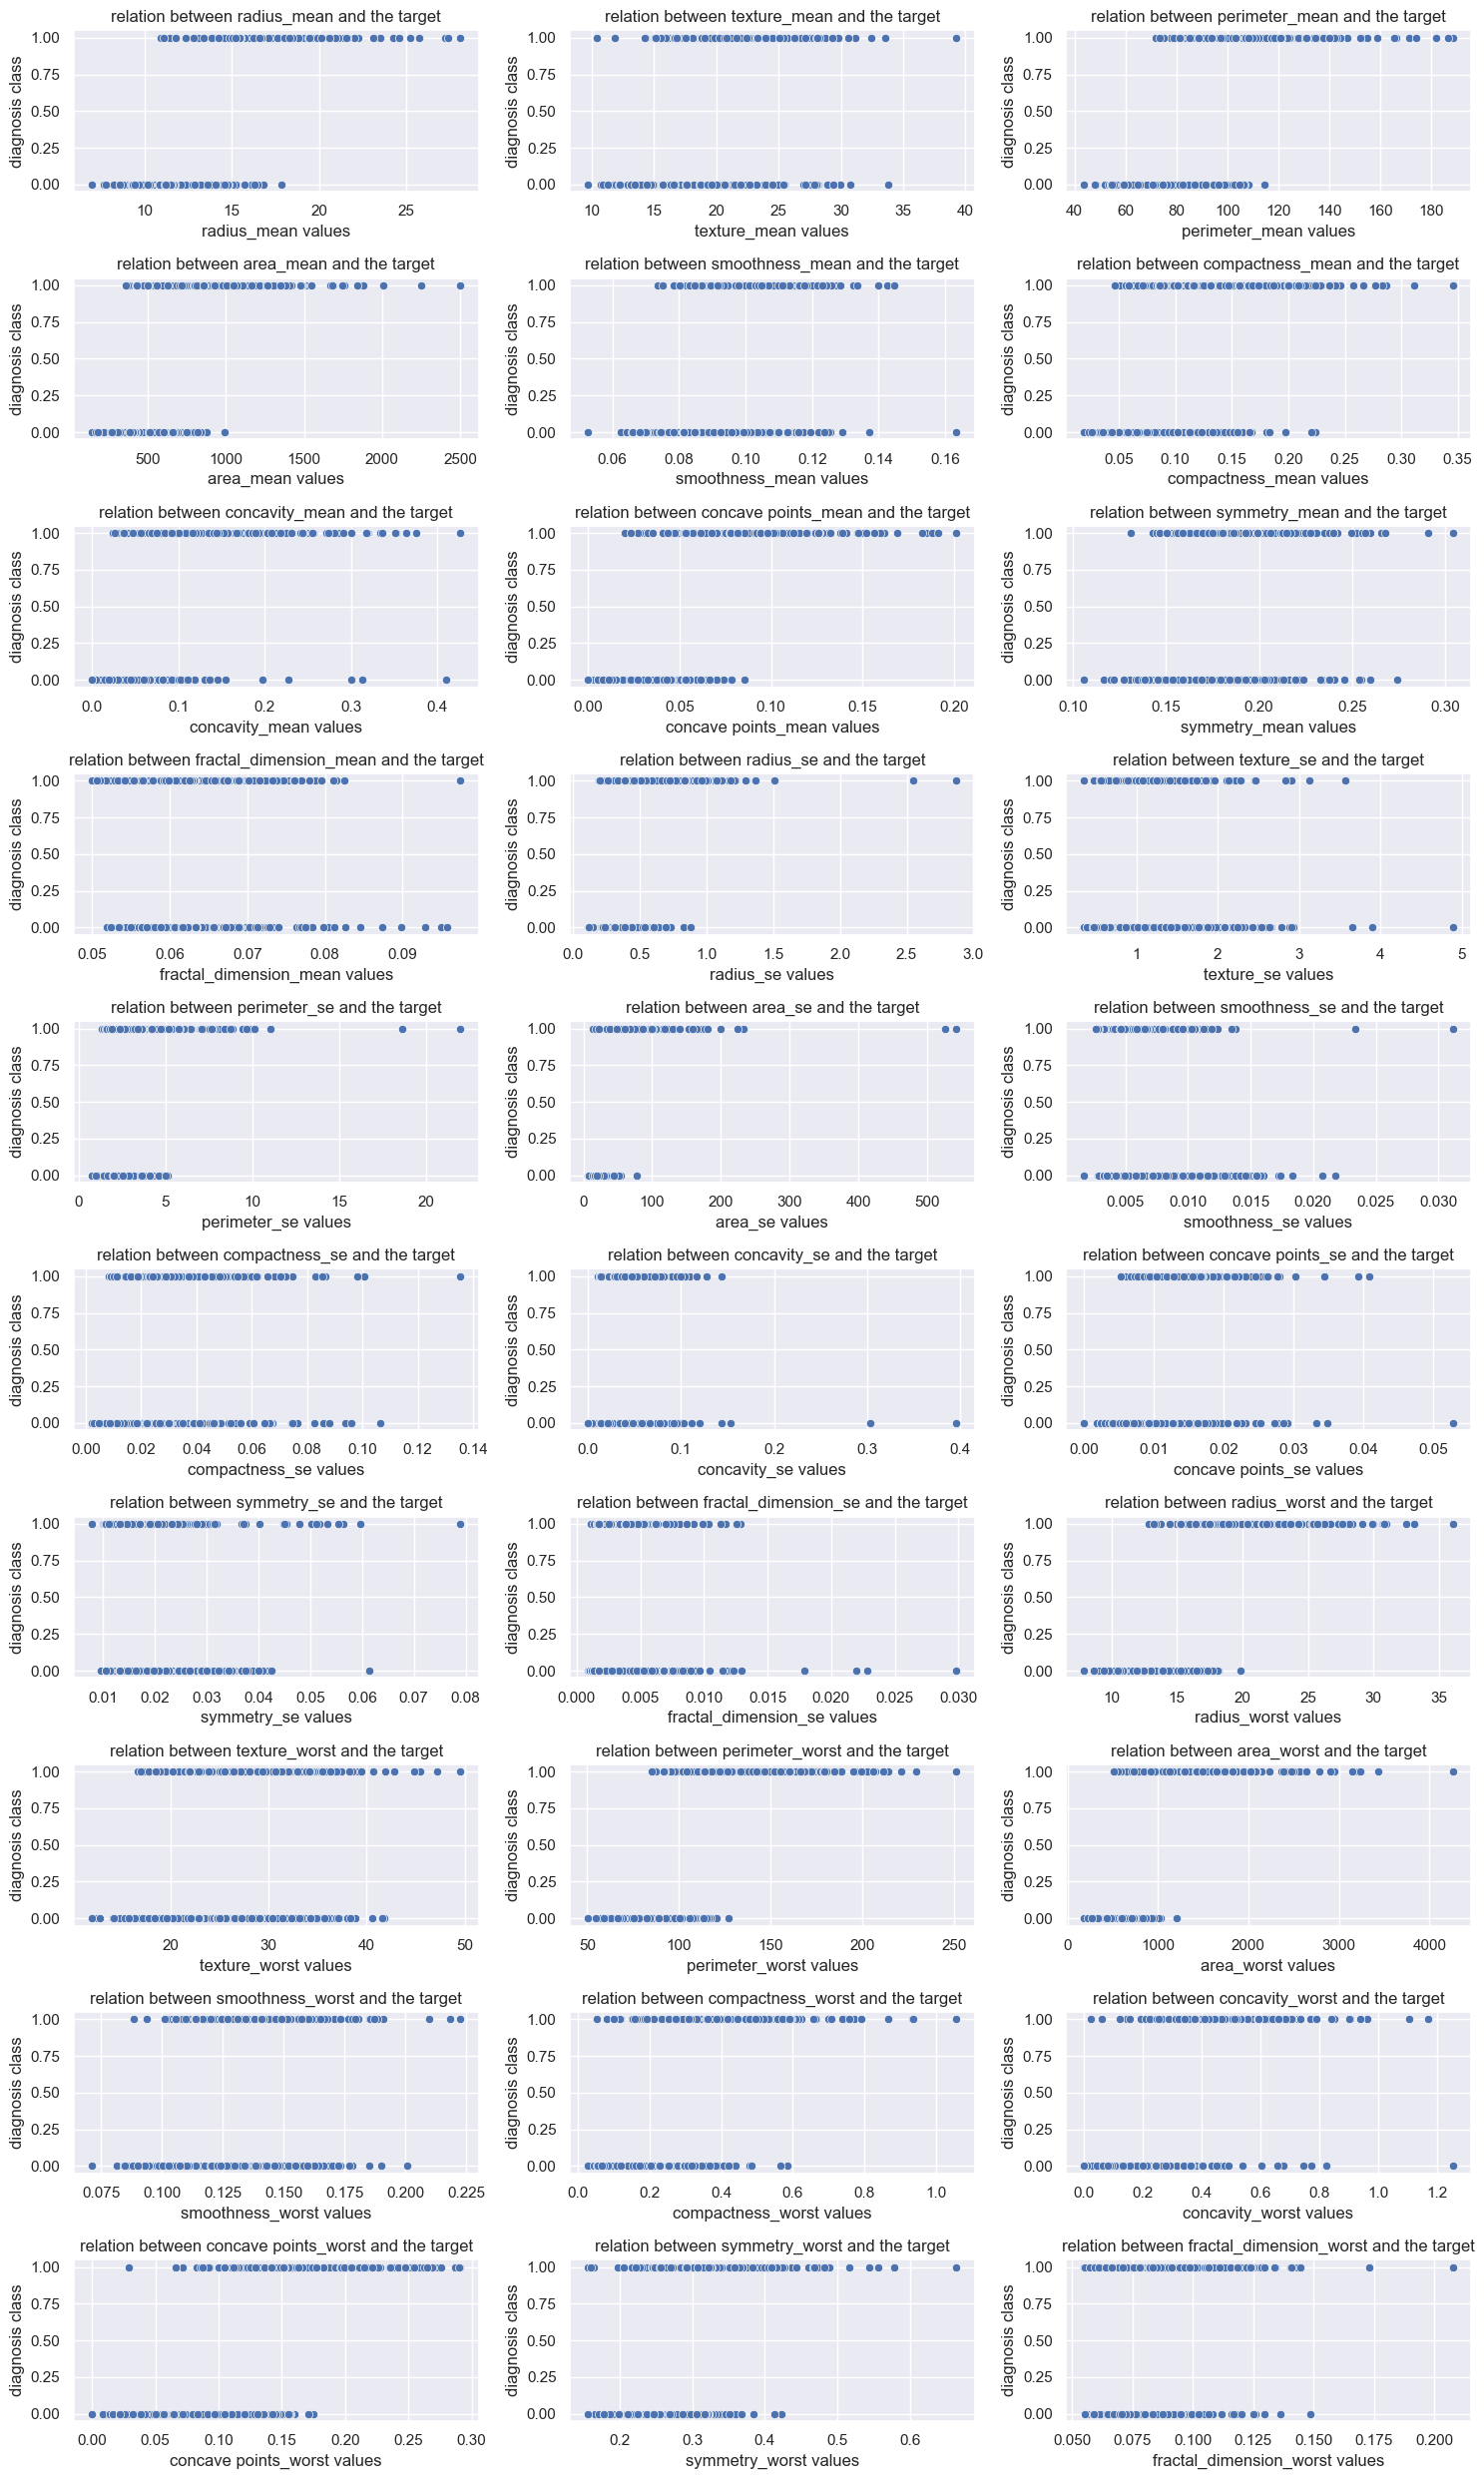

In [22]:
# display the relation between the features the the target as scatter
plt.figure(figsize=(15,25))
index = 1
for col in df.select_dtypes(include='float64'):
    plt.subplot(10,3,index)
    sns.scatterplot(data = df , y = 'Diagnosis_num' , x = col )
    plt.title(f'relation between {col} and the target')
    plt.ylabel('diagnosis class')
    plt.xlabel(f'{col} values')
    index += 1
plt.tight_layout()
plt.show()

from all these figures , the data is so suitable for logistic regression and sigmoid function

# more visualization 

In [23]:
# relation between radius mean and texture mean columns colored by target
fig = px.scatter(data_frame= df , x = 'radius_mean' , y = 'texture_mean' , color='Diagnosis')
fig.update_layout(
    title='relation between mean radius and mean texture colored by target' ,
    title_x = 0.5
)

relationship between these 2 columns is weak linear and the more radius mean grows the more texture mean grows and Malignant cases starts showing

In [24]:
# relation between perimeter mean and concavity worst colored by the target
fig = px.scatter(data_frame= df , x = 'perimeter_mean' , y = 'concavity_worst' , color='Diagnosis')
fig.update_layout(
    title='relation between mean perimeter and worst concavity colored by target' ,
    title_x = 0.5
)

relation between these 2 features is weak linear and the more the values grows Malignant cases starts showing 

In [25]:
# relation between perimeter mean and fractal dimension worst colored by target
fig = px.scatter(data_frame= df , x = 'perimeter_mean' , y = 'fractal_dimension_worst' , color='Diagnosis')
fig.update_layout(
    title='relation between mean perimeter and worst fractal dimension colored by target' ,
    title_x = 0.5
)

these 2 features almost doesn’t affect each other , and the more perimeter values grows Malignant cases starts showing

In [26]:
# 3D plot to visualize the relation between radius mean , perimeter mean ans area mean colored by target
fig = px.scatter_3d(data_frame= df , x = 'radius_mean' , y = 'perimeter_mean' ,z = 'area_mean', color='Diagnosis')
fig.update_layout(
    title='relation between mean radius ,  perimeter mean and area mean colored by target' ,
    title_x = 0.5
)

they have strong non-linear relationship the more the values grows Malignant cases starts showing

from all the past figures , it’s the same conclusion that the more the values grows the more the disease cases start to show

# splitting the data

In [27]:
# splitting the dataframe into x and y 
x = df.drop(columns=['Diagnosis' ,'Diagnosis_num'])
y = df.Diagnosis

In [28]:
# splitting the data into train and test datasets
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42 , stratify=y)

In [29]:
# check class balance in the train data
y_train.value_counts()

B    285
M    170
Name: Diagnosis, dtype: int64

# data preprocessing

In [30]:
# encoding target feature
from sklearn.preprocessing import OrdinalEncoder
order = [['B' ,'M']]
ord_en = OrdinalEncoder(categories=order)
y_train = ord_en.fit_transform(y_train.values.reshape(-1,1))
y_test = ord_en.transform(y_test.values.reshape(-1,1))

In [31]:
# splitting normal vs right skewed features
from scipy.stats import skew

# evaluate the skewness for each numerical feature
skewness = df.select_dtypes(include=['float64']).apply(lambda x: skew(x))

# splitting based on the value of skewness
normal_like = skewness[(skewness > -0.5) & (skewness < 0.5)].index.tolist()
right_skewed = skewness[skewness >= 0.5].index.tolist()


print("Almost Normally Distributed Columns:")
print(normal_like)

print("\nRight Skewed Columns:")
print(right_skewed)



Almost Normally Distributed Columns:
['smoothness_mean', 'texture_worst', 'smoothness_worst', 'concave points_worst']

Right Skewed Columns:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'perimeter_worst', 'area_worst', 'compactness_worst', 'concavity_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [32]:
# using log transform for right skewed data
x_train[right_skewed] = np.log1p(x_train[right_skewed])
x_test[right_skewed] = np.log1p(x_test[right_skewed])

In [33]:
# using z-score scaling for all features
from sklearn.preprocessing import StandardScaler
st_sc = StandardScaler()
x_train = pd.DataFrame(st_sc.fit_transform(x_train), columns=x_train.columns, index=x_train.index)

x_test = pd.DataFrame(st_sc.transform(x_test), columns=x_test.columns, index=x_test.index)

using smote algorithm to solve the imbalance in the class data

In [34]:
from imblearn.over_sampling import SMOTE


smote = SMOTE(random_state=42)

x_train_res, y_train_res = smote.fit_resample(x_train, y_train.squeeze())

print("before SMOTE:\n", pd.Series(y_train.squeeze()).value_counts())
print("after SMOTE:\n", pd.Series(y_train_res).value_counts())

before SMOTE:
 0.0    285
1.0    170
dtype: int64
after SMOTE:
 1.0    285
0.0    285
dtype: int64


In [35]:
# printing y_train values after using SMOTE algorithm
y_train_res

array([1., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 1., 1.,
       0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0.,
       0., 1., 1., 1., 1., 1., 0., 1., 0., 1., 1., 0., 0., 0., 1., 0., 0.,
       1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0.,
       1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0.,
       1., 0., 1., 0., 0., 1., 1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 1.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 1., 0., 1., 1., 1., 0., 0., 1., 1., 0., 0.,
       1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 0., 1., 1., 1., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0.,
       1., 1., 1., 0., 0.

In [36]:
# convert x_train after using SMOTE algorithm on it to numpy array of values
x_train_res  = x_train_res.values
x_train_res

array([[ 6.29769617e-01,  9.30166564e-01,  5.54135094e-01, ...,
        -2.35743918e-01,  8.02993446e-02,  3.04641799e-02],
       [-4.64181832e-01, -1.92778704e+00, -4.88607837e-01, ...,
        -3.23207881e-01, -1.18208085e-01, -9.15521274e-01],
       [-2.90046754e-01,  5.43565489e-01, -3.04069923e-01, ...,
        -8.90825037e-01, -6.84492498e-01, -1.37841550e-01],
       ...,
       [ 1.10251843e+00,  3.76935471e-01,  1.12417443e+00, ...,
         5.29386640e-01, -7.81931235e-01, -4.16785069e-01],
       [ 1.58381902e+00,  2.13092464e-01,  1.57676731e+00, ...,
         1.60523982e+00,  4.09820097e-01, -1.00650811e-01],
       [-5.73905477e-02, -1.43595304e-01,  8.77595084e-04, ...,
         6.36221727e-01,  1.24280837e+00,  1.13219635e+00]])

# model

In [37]:
# initializing  logistic regression model
from sklearn.linear_model import LogisticRegression
LogR = LogisticRegression(max_iter=1000)

In [38]:
# fit the model on train data
LogR.fit(x_train_res , y_train_res)

LogisticRegression(max_iter=1000)

# model evaluation

In [39]:
# make prediction on the test data
y_test_pred = LogR.predict(x_test)

In [40]:
# pring confusion matrix for the test data
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test , y_test_pred)

array([[71,  1],
       [ 2, 40]], dtype=int64)

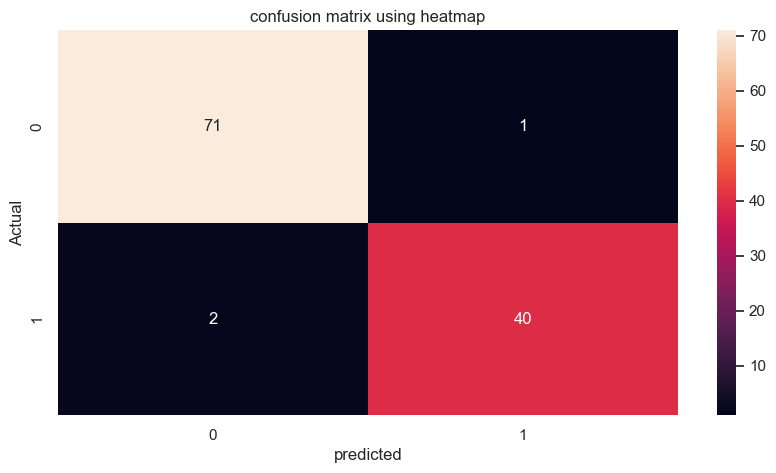

In [41]:
# visualize the confusion matrix using heatmap
plt.figure(figsize=(10,5))
sns.heatmap(confusion_matrix(y_test , y_test_pred) , annot=True)
plt.title('confusion matrix using heatmap')
plt.xlabel('predicted')
plt.ylabel('Actual')
plt.show()

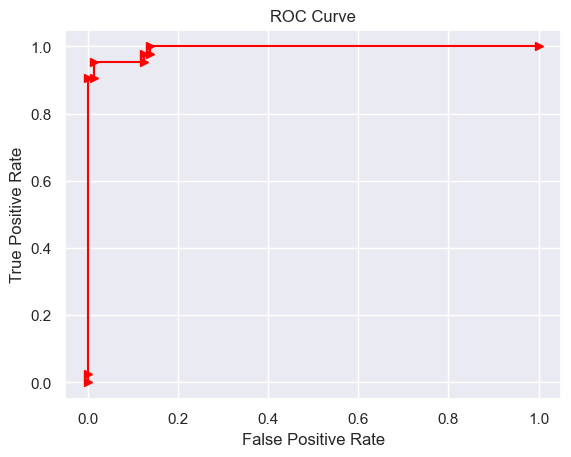

In [42]:
# visualizing the roc curve
from sklearn.metrics import roc_auc_score , roc_curve
y_prob = LogR.predict_proba(x_test)[: , 1]
fpr , tpr , _ = roc_curve(y_test , y_prob)
plt.plot(fpr, tpr, marker='>' , c='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [43]:
# print the auc values
auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc_score:.3f}")

AUC Score: 0.993


In [44]:
# printing classifiction report for the test data
from sklearn.metrics import classification_report
print('classification report values is :' , end='\n\n')
print(classification_report(y_test  , y_test_pred))

classification report values is :

              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98        72
         1.0       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



# model interpretation

### testing for underfitting and overfitting

In [45]:
# make prediction on the train data
y_train_pred = LogR.predict(x_train)

In [46]:
# comparing train accuracy vs test accuracy
from sklearn.metrics import accuracy_score
print(f'the accuracy on the trainig data = {accuracy_score(y_train , y_train_pred)}')
print('--------------------------------------')
print(f'the accuracy on the test data = {accuracy_score(y_test , y_test_pred)}')

the accuracy on the trainig data = 0.9824175824175824
--------------------------------------
the accuracy on the test data = 0.9736842105263158


### observations
- the model performs very well on both training and testing data however accuracy on the testing data is a bit lower
- based on the accuracy form both training and testing , model doesn’t suffer from underfitting or overfitting
- the model has failed in 2 cases in false negative and 1 in false positive
- the consequences is that 2 from every 42 people who has the disease will be classified as normal and 1 from every 72 people who doesn’t have the disease will be classified as patient
- we should focus on the false negative since we don’t want any patients to be classified as normal

# *thanks*